In [63]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.common.exceptions import NoSuchElementException, StaleElementReferenceException 
import time
import random
import os

def click_cookies(driver):
    try:
        button = driver.find_element(By.ID, 'didomi-notice-agree-button')
        button.click()
    except (NoSuchElementException, StaleElementReferenceException):
        pass


def save_html_file(driver, page):
    html = driver.page_source
    os.makedirs('html_file', exist_ok=True)
    with open(f'html_file/{page}.html', 'w', encoding='utf-8') as f:
        f.write(html)


    
def download_pages():
    url_template = 'https://www.csfd.cz/zebricky/filmy/nejlepsi/?from={page}'
    
    # Vytvoření instance voleb pro Chrome
    chrome_options = Options()
    # Toto je experimentální volba, která "odepne" prohlížeč od skriptu po jeho dokončení
    chrome_options.add_experimental_option("detach", True)

    # Spuštění driveru s nastavenými volbami
    driver = webdriver.Chrome(options=chrome_options)

# https://www.csfd.cz/zebricky/filmy/nejlepsi/?from={page}
# https://www.csfd.cz/zebricky/filmy/nejlepsi/?from=100
    
    driver.get('https://www.csfd.cz')
    click_cookies(driver)

    for page in (1, 100, 200, 300, 400, 500, 600, 700, 800, 900):
        driver.get(url_template.format(page=page))
        save_html_file(driver, page)
        time.sleep(random.randint(2, 5))
    
   # print(driver.page_source) - můžu smazat

In [65]:
download_pages()

In [137]:
import os
from bs4 import BeautifulSoup

DIR = 'html_file'
# velkým písmem je konstanta

files = os.listdir('html_file')

all_movies = []

for file in files:
    if file.endswith('.html'):
        with open(f"{DIR}/{file}", encoding='utf-8') as f:
            html = f.read()
    
        soup = BeautifulSoup(html, 'html.parser')
        box = soup.find('div', class_='box-content box-content-striped-articles')
        movies = box.find_all('article')
        for movie in movies:
            position = movie.find('span', class_='film-title-user').text.strip()
            position = position.replace('.', '')
            position = int(position)
    
            movie_name = movie.find('a', class_='film-title-name')['title']
            
            year = movie.find('span', class_='film-title-info').text.strip()
            year = year.replace('(', '').replace(')', '')
            year = int(year)
    
            rating = movie.find('div', class_= 'rating-average').text.strip()
            rating = rating.replace('%', '').replace(',', '.')
            rating = float(rating)
    
            rating_total = movie.find('div', class_= 'rating-total').text.strip()
            rating_total = rating_total.split(' ')[0].replace('\xa0', '')
            rating_total = int(rating_total)
    
            movie_data = {
                'position': position, 
                'name': movie_name,
                'year': year,
                'rating': rating,
                'rating_total': rating_total
            }
    
            all_movies.append(movie_data)

In [138]:
import pandas as pd

df = pd.DataFrame(all_movies)

In [234]:
df.head(10)

,position,name,year,rating,rating_total
0,1,Vykoupení z věznice Shawshank,1994,95.4,114018
1,2,Forrest Gump,1994,94.4,129336
2,3,Zelená míle,1999,92.9,110100
3,4,Sedm,1995,92.5,99804
4,5,Přelet nad kukaččím hnízdem,1975,92.4,81997
5,6,Schindlerův seznam,1993,92.4,76226
6,7,Kmotr,1972,91.8,71459
7,8,Dvanáct rozhněvaných mužů,1957,91.4,38729
8,9,Nedotknutelní,2011,91.3,82086
9,10,Pelíšky,1999,91.2,116359


In [140]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   position      1000 non-null   int64  
 1   name          1000 non-null   object 
 2   year          1000 non-null   int64  
 3   rating        1000 non-null   float64
 4   rating_total  1000 non-null   int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 39.2+ KB


In [145]:
# Jiná verze:
# def get_years(df):
#     df_year = df.groupby('year').count().reset_index()
#     df_year = df_year[['year', 'position']]
#     df_year = df_year.rename(columns={'position': 'count'})
#     df_year

#     return df_year

def get_years(df):
    df_year = df[['year', 'position']].groupby('year').count().reset_index()
    df_year = df_year.rename(columns={'position': 'count'})
    
    return df_year

In [190]:
# import matplotlib.pyplot as plt

# df_year = get_years(df)
# plt.figure(figsize=(15, 3))
# plt.bar(df_year['year'], df_year['count' ])

# plt.title("Nejlepších 1000 filmů podle roku")
# plt.xlabel("Rok")
# plt.ylabel("Počet filmů")

# plt.xticks(range(1920, 2030, 1), rotation=90)

# plt.grid()

# plt.show()

In [196]:
import matplotlib.pyplot as plt

def save_year_fig(df):
    df_year = get_years(df)
    plt.figure(figsize=(10, 5))
    plt.bar(df_year['year'], df_year['count' ])
    
    plt.title("Nejlepších 1000 filmů podle roku")
    plt.xlabel("Rok")
    plt.ylabel("Počet filmů")
    
    plt.xticks(range(1920, 2030, 5), rotation=90)
    
    plt.grid()
    plt.savefig('movies_by_year.png')
    plt.show()
    plt.close()
    

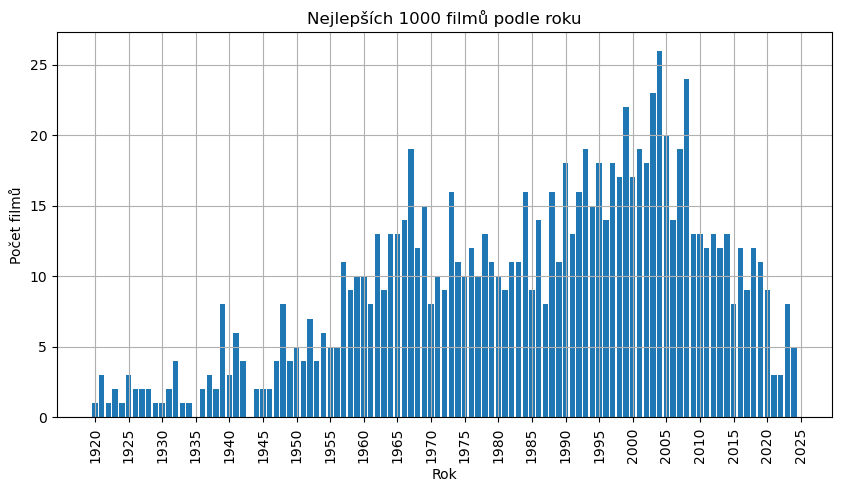

In [198]:
save_year_fig(df)

In [212]:
def save_rating_histogram(df):
    plt.figure(figsize=(10, 5))
    plt.hist(df['rating'], bins=20, color='skyblue', edgecolor='black')
    
    plt.title("Histogram hodnocení filmů")
    plt.xlabel("Hodnocení (%)")
    plt.ylabel("Počet filmů")
    
    plt.grid()
    plt.tight_layout()
    plt.savefig('ratings_histogram.png')
    plt.show()
    plt.close()

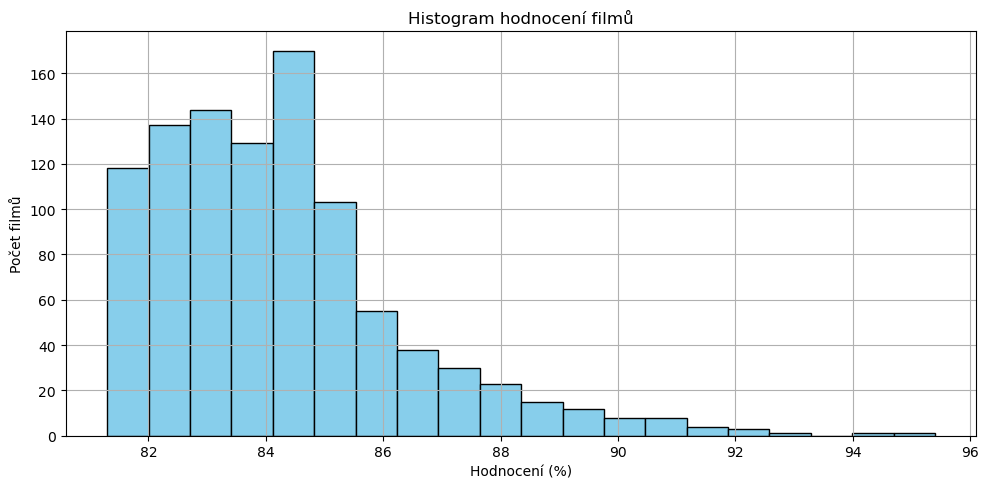

In [214]:
save_rating_histogram(df)

In [216]:
def save_rating_vs_total(df):
    plt.figure(figsize=(10, 6))
    plt.scatter(df['rating'], df['rating_total'], alpha=0.5, color='purple')
    
    plt.title("Závislost: Hodnocení vs. Počet hodnocení")
    plt.xlabel("Hodnocení (%)")
    plt.ylabel("Počet hodnocení")
    
    plt.grid()
    plt.tight_layout()
    plt.savefig('rating_counts.png')
    plt.show()
    plt.close()

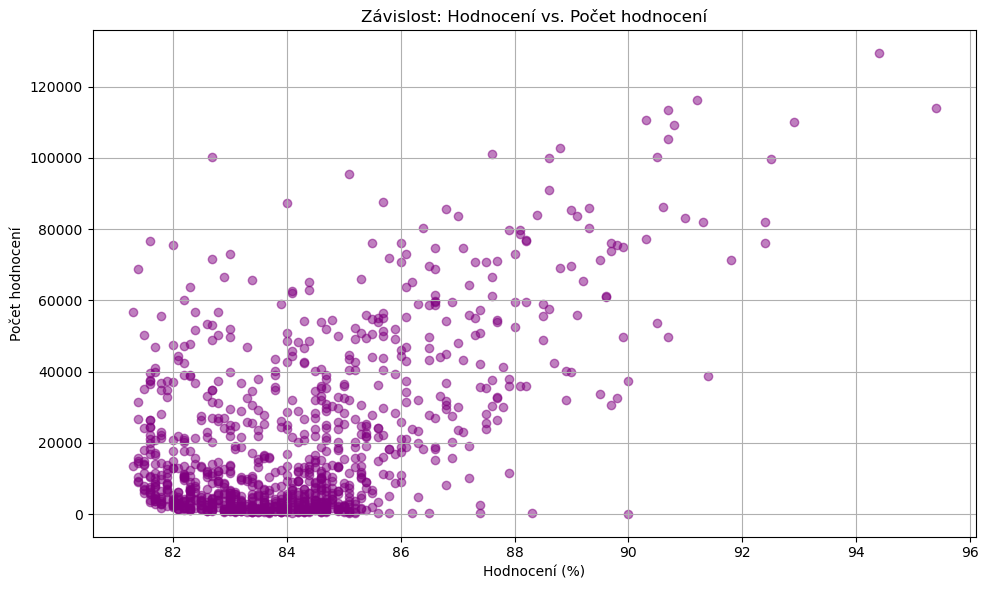

In [218]:
save_rating_vs_total(df)

In [236]:
# Vybereme TOP 10 filmů
df_top10 = df.head(10)

# Vybereme požadované sloupce a případně přejmenujeme
df_top10 = df_top10[["position", "name", "year", "rating", "rating_total"]]
df_top10.columns = ["Pořadí", "Název", "Rok", "Hodnocení", "Počet hodnocení"]

# Převedeme do formátu pro reportlab Table
hlavicka = df_top10.columns.tolist()
data_radku = df_top10.values.tolist()
data_pro_tabulku = [hlavicka] + data_radku

In [240]:
from reportlab.lib.pagesizes import A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.pdfbase import pdfmetrics
from reportlab.pdfbase.ttfonts import TTFont
from reportlab.lib.enums import TA_CENTER
from reportlab.lib.units import inch, cm
from reportlab.platypus import PageBreak
from datetime import datetime 

from reportlab.platypus import Table, TableStyle
from reportlab.lib import colors

pdfmetrics.registerFont(TTFont('TimesNewRoman', 'times.ttf'))

title_style = ParagraphStyle(
    name='TitleStyle',
    fontName='TimesNewRoman',
    fontSize=24,
    leading=28,
    alignment=TA_CENTER,
    spaceAfter=20
)

h2_style = ParagraphStyle(
    name='Heading2',
    fontName='TimesNewRoman',
    fontSize=18,
    leading=22,
    alignment=TA_CENTER,
    spaceAfter=14,
    spaceBefore=14
)

graph_title_style = ParagraphStyle(
    name='GraphTitle',
    fontName='TimesNewRoman',
    fontSize=16,
    leading=20,
    alignment=TA_CENTER,
    spaceAfter=12
)

author_style = ParagraphStyle(
    name='AuthorStyle',
    fontName='TimesNewRoman',
    fontSize=16,
    alignment=TA_CENTER,
    spaceAfter=10
)

date_style = ParagraphStyle(
    name='DateStyle',
    fontName='TimesNewRoman',
    fontSize=12,
    alignment=TA_CENTER,
    spaceAfter=10
)

doc = SimpleDocTemplate("workshop.pdf", pagesize=A4)

story = []

# Titulní strana
today = datetime.today()
formatted_date = f"{today.day}. {today.month:02d}. {today.year}"

story.insert(0, Paragraph(formatted_date, date_style))
story.insert(0, Paragraph("Petra Pfeifer", author_style))
story.insert(0, Paragraph("Analýza nejlépe hodnocených filmů na ČSFD", title_style))
story.insert(0, Spacer(1, 10 * cm))
story.append(PageBreak())

# 1. graf - Počet filmů podle roku
story.append(Paragraph("Kategorie 1: Vývoj produkce filmů v čase", h2_style))
story.append(Paragraph("Počet filmů podle roku", graph_title_style))
story.append(Spacer(1, 0.5 * cm))
story.append(Image('movies_by_year.png', width=14*cm, height=8*cm))
story.append(PageBreak())

# 2. graf – Histogram hodnocení filmů
story.append(Paragraph("Kategorie 2: Distribuce hodnocení filmů", h2_style))
story.append(Paragraph("Histogram hodnocení filmů", graph_title_style))
story.append(Spacer(1, 0.5 * cm))
story.append(Image("ratings_histogram.png", width=14*cm, height=8*cm))
story.append(PageBreak())

# 3. graf – Závislost: Hodnocení vs. Počet hodnocení
story.append(Paragraph("Kategorie 3: Závislosti: Hodnocení vs. Počet hodnocení", h2_style))
story.append(Paragraph("Počet hodnocení na film", graph_title_style))
story.append(Spacer(1, 0.5 * cm))
story.append(Image("rating_counts.png", width=14*cm, height=8*cm))
story.append(PageBreak())

# Tabulka do PDF
tabulka = Table(data_pro_tabulku, colWidths=[2*cm, 6.5*cm, 2*cm, 3*cm, 3*cm])
tabulka.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.lightgrey),
    ('GRID', (0,0), (-1,-1), 0.5, colors.grey),
    ('FONTNAME', (0,0), (-1,-1), 'TimesNewRoman'),
    ('ALIGN', (0,0), (-1,-1), 'CENTER'),
    ('FONTSIZE', (0,0), (-1,-1), 11),
    ('BOTTOMPADDING', (0,0), (-1,0), 10),
]))

story.append(Paragraph("TOP 10 filmů podle hodnocení", h2_style))
story.append(Spacer(1, 0.5 * cm))
story.append(tabulka)
   
doc.build(story)